<html><span style = "font-size: 24px;"><b>Evaluation</b></span></html>

Invoer: In de testdata staan de data die gesplitst is van de originele data.
Uitvoer: Uit de keuzes van alle modellen is de keuze gevallen op Gradient boosting. Uit de fase van data modeling en preparation van Gradient boosting hebben wij de parameters verkregen die wij op de testdata hebben toegepast. Daaruit zijn de verwachte winst en prestatiematen naar voren gekomen die onderaan dit bestand staan.


In [1]:
"""
@
Auteurs:        Jeffrey Jason Boekstaaf, Tim Paulus van Croimvort en Haydar Eryörük
Studentnummers: 500460365, 500916516 en 500910901
Datum:          23-04-2026
Vak:            Beroepsproject 3.4
Opleiding:      Toegepaste Wiskunde & Data Science
School:         Hogeschool van Amsterdam
"""

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pickle
import seaborn as sns

from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, f1_score, precision_score, recall_score, RocCurveDisplay
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder

# Hier wordt de testdata ingeladen.
data_test = pd.read_csv("data_test.csv")


In [2]:
# Haalt de Gradient Boosting classifier op uit de lokale map.
with open('pipelineGB.pkl', 'rb') as file:
    gradient_boosting_pipe = pickle.load(file)


In [3]:
# Op churn wordt de voorspelling gedaan en alle andere variabelen zijn X.
train = data_test.drop(columns = ['Churn'])
Y = LabelEncoder().fit_transform(data_test['Churn'])


In [4]:
# Uit de gridsearch is dit aantal van n estimators (bomen) als beste uitgekomen en daarom dient het hier aangepast te worden.
gradient_boosting_pipe.n_estimators = 3200


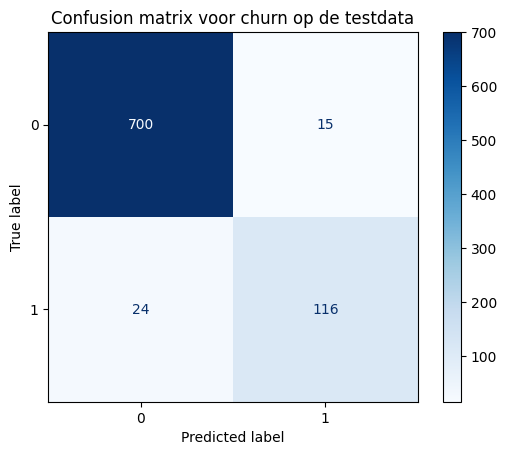

In [5]:
# Hier wordt de voorspelling gedaan op de X-variabelen van de test_data.
predicted = gradient_boosting_pipe.predict(train)

# Confusion matrix
ConfusionMatrixDisplay.from_predictions(Y, predicted, cmap = 'Blues')
plt.title("Confusion matrix voor churn op de testdata")
plt.show()


Hierboven is er te zien dat er (15 + 24) 39 miskwalificaties zijn. 15 klanten zijn voorspeld door dit model dat diegenen willen overstappen, terwijl diegenen dat niet hebben gedaan. 24 klanten zijn voorspeld door dit model dat dienegen niet willen overstappen, terwijl zij wel zijn overgestapd.
De andere klanten zijn wel goed voorspeld en daarvan zijn 116 die wel voorspeld zijn om over te stappen en zijn overgestapt. Deze groep is de een na grootste groep. De grootste groep zijn 700 klanten die niet zijn overgestapt en zijn voorspeld door het model dat diegenen ook niet willen overstappen.


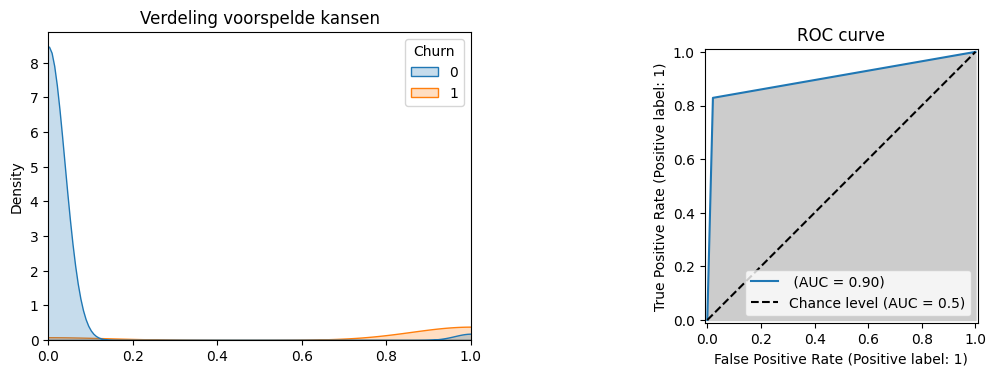

In [6]:
# Verdeling van de voorspelde kansen.
plt.figure(figsize = (12, 4))
plt.subplot(1, 2, 1)
sns.kdeplot(data_test, x = predicted[:], hue = 'Churn', fill = True)
plt.xlim(0, 1)
plt.title('Verdeling voorspelde kansen')

# ROC-curve
ax = plt.subplot(1, 3, 3)
roc = RocCurveDisplay.from_predictions(
    Y,
    predicted[:], 
    name = '', 
    plot_chance_level = True,
    ax = ax)
plt.fill_between(roc.fpr, roc.tpr, color = '0.8')
plt.title('ROC curve')
plt.show()


In de figuur hierboven zijn 2 plots weergegeven, waarbij bij de eerste plot de verdeling van de voorspelde kansen voor churn weergeeft en de laatste plot een weergave is van de ROC-curve.
Hierbij geldt voor de eerste plot dat voor een waarde van Churn is 0 geldt dat het model voorspelt dat de klant het abonnement wil opzeggen en voor een waarde van Churn 1 de klant het abonnement wil opgezeggen.

In [7]:
W = (((data_test['Seconds of Use'] / 60.0) * 0.2) + (data_test['Frequency of SMS'] * 0.07))
expected_profit = (1 - (0.25 * predicted)) * W
print("De winstverwachting is: €", (round(expected_profit.sum(), 2)), sep = "", end = ".")


De winstverwachting is: €18074.49.

In [8]:
# Hier worden de accuracy, f1, precision en recall scores berekend en gegeven.
acc = round(accuracy_score(Y, predicted), 2)
rec = round(recall_score(Y, predicted), 2)
pre = round(precision_score(Y, predicted), 2)
fsco = round(f1_score(Y, predicted), 2)
table = {"Name": ["Accuracy", "Recall", "Precision", "F1-score"],
        "Value": [acc, rec, pre, fsco]}
df = pd.DataFrame(table)
df


,Name,Value
0,Accuracy,0.95
1,Recall,0.83
2,Precision,0.89
3,F1-score,0.86
